# DQN with Acrobot-v1 Environment

This notebook loads [config.yaml](config.yaml) and trains the `QAgent` on `Acrobot-v1` using the Gymnassium API for envrionment.

Acrobot has a `Box(6,)` **observation space** and a `Discrete(3)` **action space**, so DQN uses the continuous state and the native discrete actions while training, during analysis we break it down based on our analysis discretisation config to look at the various statistics.

## Imports

In [1]:
import sys, pathlib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Config-driven wiring: change config.yaml and it flows through these builders
# without editing the notebook. Hankel analysis is driven by analysis.hankel_sweep
# in config.yaml (dispatched inside the training loop), so no Hankel import here.
from experiment import load_config, build_env, build_agent, train, make_run_logger
from analysis.registry import resolve_methods
from analysis.low_rank.rank import row_rank_property_check
from analysis.visualisations.heatmaps import plot_matrix_heatmap

## Reading the `config` file

In [2]:
cfg = load_config("config.yaml")   # loads yaml, resolves device, seeds torch/numpy
print("device:", cfg["experiment"]["_device"])
cfg

device: cpu


{'experiment': {'name': 'dqn_acrobot_2',
  'seed': 52,
  'device': 'mps',
  'save_artifacts': True,
  '_device': 'cpu'},
 'environment': {'name': 'Acrobot-v1',
  'render_mode': None,
  'discrete_config': None,
  'normalise': {'action': {}, 'state': {}},
  'clip': {'action': False, 'state': []}},
 'network': {'hidden_sizes': [128, 128]},
 'agent': {'replay_buffer_capacity': 10000,
  'batch_size': 128,
  'nn_learning_rate': 0.0003,
  'eps_start': 1.0,
  'eps_min': 0.05,
  'decay_rate': 0.99995,
  'discount_factor': 0.99,
  'TD_LR': 0.005,
  'buffer_util': 1,
  'gd_steps_ceil': 1,
  'grad_clip_norm': 20.0},
 'training': {'no_episodes': 500,
  'target_network_update_steps': 2,
  'train_frequency_steps': 2,
  'use_episode_training': False,
  'solved_reward': -80,
  'warmup_steps': 5000,
  'early_stopping_patience_eps': 50,
  'no_eps_to_avg': 10},
 'analysis': {'ep_freq': 50,
  'methods': [{'name': 'q_matrix_dqn',
    'kwargs': {'state_discretisation': [8, 8, 8, 8, 8, 8], 'batch_size': 64},


## Creating the Envrionment

In [3]:
env = build_env(cfg)
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n
print("obs_dim:", obs_dim, "n_actions:", n_actions)

obs_dim: 6 n_actions: 3


## Creating the Agent

In [4]:
class QNetwork(nn.Module):
    """Maps a state (obs_dim,) -> Q-values (n_actions,). Built by QAgent via q_network(**nn_extra_kwargs)."""
    def __init__(self, in_dim, out_dim, hidden_sizes=(128, 128)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [5]:
# The net class + its derived dims are genuine code (not config keys), so they
# stay explicit; every agent hyperparameter comes from cfg["agent"] via build_agent.
nn_extra_kwargs = {
    "in_dim": obs_dim,
    "out_dim": n_actions,
    "hidden_sizes": cfg["network"]["hidden_sizes"],
}
agent = build_agent(cfg, env, QNetwork, nn_extra_kwargs)

## Analysis (Low Rank)

In [6]:
# Run artifacts (spectra figures, rewards/rank/hankel_sweep CSVs, trajectories,
# checkpoints) land under runs/<timestamp>/ when experiment.save_artifacts is set;
# otherwise logger is None and analysis renders inline. Hankel runs via the
# analysis.hankel_sweep config block (dispatched inside the training loop);
# generic methods (e.g. q_matrix_dqn) resolve from analysis/registry.py.
logger = make_run_logger(cfg)
if logger:
    print("run artifacts ->", logger.dir)

run artifacts -> /home/souparna/Low-Rank-RL-TL/experiments/dqn_acrobot_2_revised/runs/20260706-103102


## Agent Training 

In [7]:
rewards = train(cfg, agent, env, run_logger=logger)

  0%|          | 0/500 [00:00<?, ?it/s]

episode 0 avg_rewarg: -394.0
****************************Q-function****************************
eff_rank: 1, stable_rank: 1.06, spikiness: 3.28, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: row min=1.509e-17 max=2.778e-05 (uniform 3.815e-06) | col min=0.0689 max=0.4901 (uniform 0.3333)
coherence score: row=7.283 col=1.47


  2%|▏         | 8/500 [00:39<29:43,  3.63s/it]  

episode 10 avg_rewarg: -500.0


  4%|▍         | 21/500 [00:58<15:37,  1.96s/it]

...

episode 480 avg_rewarg: -115.4


 98%|█████████▊| 491/500 [05:37<00:02,  3.34it/s]

episode 490 avg_rewarg: -87.7


100%|██████████| 500/500 [05:39<00:00,  1.47it/s]

run artifacts saved under /home/souparna/Low-Rank-RL-TL/experiments/dqn_acrobot_2_revised/runs/20260706-103102


## Training and Analysis Plots (now with pi*(theeta))

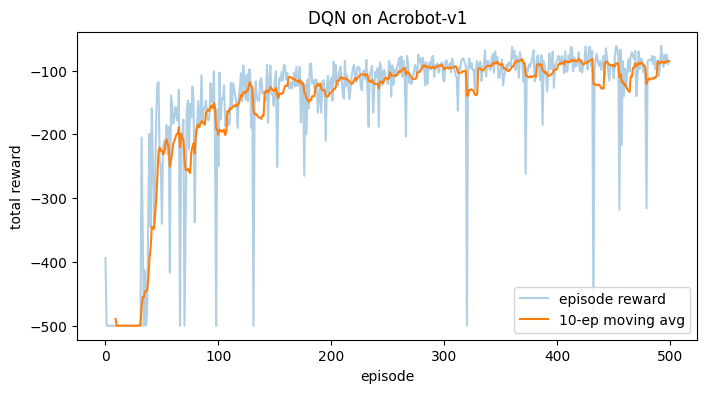

In [8]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("DQN on Acrobot-v1")
plt.legend()
if logger:
    plt.savefig(logger.dir / "reward_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Q-function


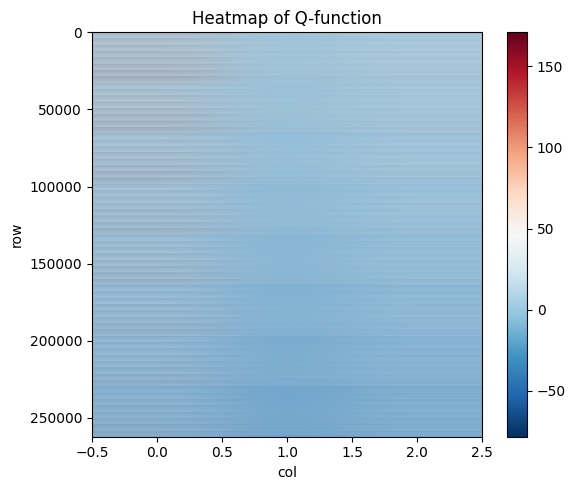

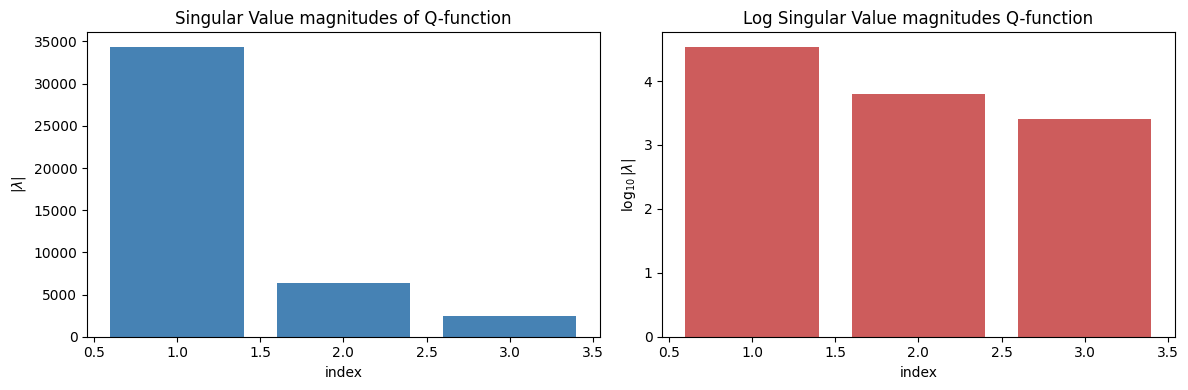

eff_rank: 1, stable_rank: 1.04, spikiness: 4.33, shape: (262144, 3), non-zero rows :262144, non-zero cols:3
top-r leverage spread: row min=4.039e-17 max=3.973e-05 (uniform 3.815e-06) | col min=0.2672 max=0.4508 (uniform 0.3333)
coherence score: row=10.42 col=1.352


In [9]:
# Post-training: run the generic per-matrix methods (e.g. q_matrix_dqn) + any
# post_methods on the final policy, showing heatmap + spectrum for each. Hankel
# already ran every ep_freq during training via hankel_sweep.
methods = resolve_methods(cfg["analysis"].get("methods", []) + cfg["analysis"].get("post_methods", []))
for method, names in methods:
    results = method(agent=agent, env=env)
    if not isinstance(results, tuple):
        results = (results,)
    for matrix, name in zip(results, names):
        print(name)
        plot_matrix_heatmap(matrix, name, save_to=logger.figure_path(f"{name} heatmap") if logger else None)
        r, sr, spk, shape, irs, ics, rc, cc, nzr, nzc = row_rank_property_check(matrix, name, save_to=logger.figure_path(name) if logger else None)
        print(f"eff_rank: {r}, stable_rank: {sr:.2f}, spikiness: {spk:.2f}, shape: {shape}, non-zero rows :{nzr}, non-zero cols:{nzc}")
        print(f"top-r leverage spread: row min={irs.min():.4g} max={irs.max():.4g} (uniform {1.0/shape[0]:.4g}) | col min={ics.min():.4g} max={ics.max():.4g} (uniform {1.0/shape[1]:.4g})")
        print(f"coherence score: row={rc:.4g} col={cc:.4g}")

## Greedy rollout video

Record one greedy (`act_greedy`) episode of the trained `agent` and display it inline. The eval env is rebuilt with `render_mode="rgb_array"` so frames can be captured.

In [10]:
# Greedy rollout video of the trained agent
from analysis.visualisations.rollout_video import record_greedy_episode
from IPython.display import Video
import glob

video_dir = "videos"
eval_env = build_env(cfg, render_mode="rgb_array")
prefix = record_greedy_episode(agent, eval_env, video_dir, episode=0, seed=cfg["experiment"]["seed"])
mp4 = sorted(glob.glob(f"{video_dir}/{prefix}-*.mp4"))[-1]
print("saved:", mp4)
Video(mp4, embed=True)

saved: videos/ep0-episode-0.mp4
